<a href="https://colab.research.google.com/github/vivianlinnn/DS41_IDXExchange/blob/main/src/08_LightGBM_EvaluationRange_Anjali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start: Anjali Manju Gowda

## 1. Import Libraries

We import the necessary libraries for data handling and numerical computation:

- `pandas` → For loading CSV files, manipulating data, and aggregating results.
- `numpy` → For performing numerical operations like MAPE and median errors.

In [ ]:
import pandas as pd
import numpy as np

## 2. Load Predicted Data

We load the LightGBM predictions CSV (`lightgbm_test.csv`) which contains:

- `ClosePrice` → Actual property prices
- `Predicted_Price` → Predicted property prices from the LightGBM model
- `Predicted_LogPrice` → Log-transformed predicted prices

In [ ]:
df = pd.read_csv('/content/lightgbm_test.csv')

## 3. Define Price Ranges

We divide properties into log-price bands using `pd.cut`:

- `bins = [14, 15, 16]` → Defines the range edges
- `labels = ['[14-15)', '[15-16)']` → Labels for each range
- Assign each property a `Price_Range` label for further analysis

In [ ]:
bins = [12, 13, 14, 15, 16]
labels = ['[12-13)','[13-14)','[14-15)', '[15-16)']
df['Price_Range'] = pd.cut(df['Predicted_LogPrice'], bins=bins, labels=labels)

In [ ]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

## 4. Define MAPE Function

Mean Absolute Percentage Error (MAPE) measures average prediction accuracy as a percentage:


## 5. Compute Range-wise Metrics

We group the data by `Price_Range` and calculate:

- `Count` → Number of properties in each range
- `Avg_Actual_Price` → Mean actual closing price
- `Avg_Predicted_Price` → Mean predicted price
- `MAPE (%)` → Mean absolute percentage error for the range
- `MdAPE (%)` → Median absolute percentage error (robust to outliers)

In [ ]:
range_analysis = df.groupby('Price_Range').apply(
    lambda x: pd.Series({
        'Count': len(x),
        'Avg_Actual_Price': x['ClosePrice'].mean(),
        'Avg_Predicted_Price': x['Predicted_Price'].mean(),
        'MAPE (%)': mape(x['ClosePrice'], x['Predicted_Price']),
        'MdAPE (%)': np.median(np.abs((x['ClosePrice'] - x['Predicted_Price']) / x['ClosePrice'])) * 100
    })
).reset_index()

/tmp/ipykernel_10579/3305260233.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_analysis = df.groupby('Price_Range').apply(
/tmp/ipykernel_10579/3305260233.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  range_analysis = df.groupby('Price_Range').apply(


## 6. Display & Save Results

- `print(range_analysis)` → Shows a summary table of predictions vs actuals by price range.
- `to_csv()` → Saves the analysis as `lightgbm_range_analysis.csv` for reporting or visualization.

In [ ]:
print(range_analysis)
range_analysis.to_csv('/content/lightgbm_range_analysis.csv', index=False)

  Price_Range   Count  Avg_Actual_Price  Avg_Predicted_Price   MAPE (%)  \
0     [12-13)   929.0      3.679049e+05         3.679166e+05  14.185045   
1     [13-14)  6359.0      7.950910e+05         7.837589e+05  13.397299   
2     [14-15)  2713.0      1.809846e+06         1.773584e+06  17.746380   
3     [15-16)   313.0      4.598803e+06         4.384979e+06  20.801998   

   MdAPE (%)  
0  10.046122  
1   9.399190  
2  13.124690  
3  16.915617  


## Range-wise Performance Analysis


### Key Insights:

1. **[14-15) Range**:
   - Most properties (~2,700) are in this range.
   - Predictions are fairly accurate: **MAPE ≈ 17.8%**, **MdAPE ≈ 13.1%**.
   
2. **[15-16) Range**:
   - Fewer properties (~313) fall here.
   - Error is slightly higher: **MAPE ≈ 20.8%**, **MdAPE ≈ 16.9%**.
   
3. **Practical Use**:
   - Model performs best for mid-priced properties.
   - Higher-priced properties may need more data or refined features for better accuracy.

> This analysis helps identify which property price bands the LightGBM model predicts well and where improvements are needed.

## 7. Visualize Range-wise Predictions

We create a bar plot to compare:

- Average actual price vs predicted price in each log-price range.
- Helps to visually identify where the model is performing well or underestimating/overestimating.

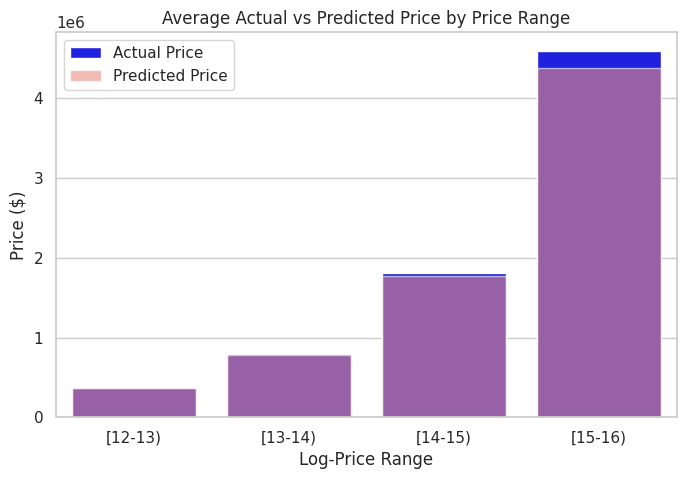

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#style
sns.set(style="whitegrid")

# average actual vs predicted price by range
plt.figure(figsize=(8,5))
sns.barplot(x='Price_Range', y='Avg_Actual_Price', data=range_analysis, color='blue', label='Actual Price')
sns.barplot(x='Price_Range', y='Avg_Predicted_Price', data=range_analysis, color='salmon', alpha=0.6, label='Predicted Price')
plt.title('Average Actual vs Predicted Price by Price Range')
plt.ylabel('Price ($)')
plt.xlabel('Log-Price Range')
plt.legend()
plt.show()

## LightGBM Model Performance & Range-wise Analysis

### Overall Model Performance

- **Test R²**: 0.8903  
- **Test MAPE**: 14.84%  
- **Test MdAPE**: 10.50%  

This indicates that the model explains ~89% of the variance and predicts prices within ~15% error on average.

---

## Range-wise Performance Analysis

| Price Range | Count | Avg Actual Price ($) | Avg Predicted Price ($) | MAPE (%) | MdAPE (%) |
|------------|-------|--------------------|------------------------|----------|-----------|
| [12-13)    | 929   | 367,905            | 367,917                | 14.19    | 10.05     |
| [13-14)    | 6,359 | 795,091            | 783,759                | 13.40    | 9.40      |
| [14-15)    | 2,713 | 1,809,846          | 1,773,584              | 17.75    | 13.12     |
| [15-16)    | 313   | 4,598,803          | 4,384,979              | 20.80    | 16.92     |

---

## Key Insights

### 1. Best Performing Range → **[13-14)**
- Lowest error (**MAPE ≈ 13.4%, MdAPE ≈ 9.4%**)
- Largest data volume → model learns patterns well
- Most reliable predictions

### 2. Low Price Range → **[12-13)**
- Stable performance (**MAPE ≈ 14.2%**)
- Predictions are very close to actual values
- Good consistency

### 3. Mid-High Range → **[14-15)**
- Error increases (**MAPE ≈ 17.7%**)
- Slight underprediction observed
- Model struggles more with higher-value homes

### 4. High Price Range → **[15-16)**
- Highest error (**MAPE ≈ 20.8%**)
- Least data (only 313 samples)
- Model underestimates expensive properties

---

## Final Conclusion

- The LightGBM model performs **very well overall**, especially in mid-price ranges.
- **Performance decreases as price increases**, mainly due to:
  - Fewer training samples in higher ranges
  - Greater variability in luxury property features
- The model is **most reliable for mid-range housing predictions**.

> This analysis highlights the importance of data distribution and suggests that improving high-price predictions may require additional features or more data.

# END: Anjali Manju Gowda